In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 数据处理和可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 统计分析
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# 机器学习
from sklearn.linear_model import Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False
# 读取数据
df = pd.read_csv('../extracted_data/stk_100.csv')
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values('trade_date').reset_index(drop=True)

print("数据基本信息:")
print(f"数据范围: {df['trade_date'].min()} 至 {df['trade_date'].max()}")
print(f"总样本数: {len(df)}")
print("\n前5行数据:")
print(df.head())
print("\n数据统计描述:")
print(df[['open', 'high', 'low', 'close', 'vol', 'amount']].describe())

数据基本信息:
数据范围: 2024-01-02 00:00:00 至 2025-01-10 00:00:00
总样本数: 24678

前5行数据:
     ts_code trade_date   open   high    low  close  pre_close  change  \
0  000005.SZ 2024-01-02   1.08   1.12   1.08   1.12       1.07    0.05   
1  688092.SH 2024-01-02  30.80  31.25  30.76  31.09      30.76    0.33   
2  605358.SH 2024-01-02  27.48  27.48  26.89  27.09      27.39   -0.30   
3  002068.SZ 2024-01-02  11.60  11.66  11.38  11.57      11.60   -0.03   
4  605338.SH 2024-01-02  21.48  21.70  21.10  21.56      21.48    0.08   

   pct_chg        vol      amount  
0   4.6729   63028.00    6967.071  
1   1.0728    7550.29   23439.248  
2  -1.0953   59934.93  162497.330  
3  -0.2586  154258.25  177248.713  
4   0.3724   16390.12   35207.555  

数据统计描述:
               open          high           low         close           vol  \
count  24678.000000  24678.000000  24678.000000  24678.000000  2.467800e+04   
mean      18.605848     19.047486     18.190821     18.598377  2.186629e+05   
std       23.5621

In [3]:
# ==================== 1. 基础技术面因子计算 ====================

def calculate_technical_factors(df):
    """计算基础技术面因子"""
    df_factor = df.copy()
    
    # 1. 收益率因子
    df_factor['ret_1d'] = df_factor['close'].pct_change()
    df_factor['ret_5d'] = df_factor['close'].pct_change(5)
    df_factor['ret_10d'] = df_factor['close'].pct_change(10)
    df_factor['ret_20d'] = df_factor['close'].pct_change(20)
    
    # 2. 均线因子 (MA)
    for period in [5, 10, 20, 30]:
        df_factor[f'MA_{period}'] = df_factor['close'].rolling(period).mean()
        df_factor[f'MA_ratio_{period}'] = df_factor['close'] / df_factor[f'MA_{period}'] - 1
        
    # 3. 均线斜率因子
    for period in [5, 10, 20, 30]:
        df_factor[f'slope_{period}'] = df_factor[f'MA_{period}'] - df_factor[f'MA_{period}'].shift(1)
        # 避免除零
        denom = df_factor[f'slope_{period}'].shift(1)
        df_factor[f'slope_ratio_{period}'] = np.where(
            np.abs(denom) > 1e-10,
            df_factor[f'slope_{period}'] / denom,
            np.nan
        )
        
    # 4. 波动率因子
    df_factor['volatility_10d'] = df_factor['ret_1d'].rolling(10).std()
    df_factor['volatility_20d'] = df_factor['ret_1d'].rolling(20).std()
    
    # 5. ATR因子
    tr = np.maximum(
        df_factor['high'] - df_factor['low'],
        np.maximum(
            abs(df_factor['high'] - df_factor['close'].shift(1)),
            abs(df_factor['low'] - df_factor['close'].shift(1))
        )
    )
    df_factor['ATR_14'] = tr.rolling(14).mean()
    df_factor['ATR_ratio'] = df_factor['ATR_14'] / df_factor['close']
    
    # 6. RSI因子
    def calculate_rsi(data, period=14):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    df_factor['RSI_14'] = calculate_rsi(df_factor['close'], 14)
    
    # 7. 乖离率因子 (BIAS)
    for period in [5, 10, 20]:
        df_factor[f'BIAS_{period}'] = (df_factor['close'] - df_factor[f'MA_{period}']) / df_factor[f'MA_{period}'] * 100
        
    # 8. 成交量因子
    df_factor['volume_ma_5'] = df_factor['vol'].rolling(5).mean()
    df_factor['volume_ratio'] = df_factor['vol'] / df_factor['volume_ma_5']
    df_factor['amount_ma_5'] = df_factor['amount'].rolling(5).mean()
    df_factor['amount_ratio'] = df_factor['amount'] / df_factor['amount_ma_5']
    
    # 9. 价格区间因子
    df_factor['high_low_ratio'] = (df_factor['high'] - df_factor['low']) / df_factor['close']
    df_factor['close_position'] = (df_factor['close'] - df_factor['low']) / (df_factor['high'] - df_factor['low'] + 1e-10)
    
    # 10. 动量因子
    df_factor['momentum_10d'] = df_factor['close'] / df_factor['close'].shift(10) - 1
    df_factor['momentum_20d'] = df_factor['close'] / df_factor['close'].shift(20) - 1
    
    return df_factor
    
    
# 计算因子
df_factor = calculate_technical_factors(df)

print("\n因子计算结果:")
factor_cols = [col for col in df_factor.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']]
print(f"总因子数: {len(factor_cols)}")
print("\n因子数据示例:")
print(df_factor[['trade_date', 'close'] + factor_cols[:10]].iloc[100:105])


因子计算结果:
总因子数: 36

因子数据示例:
    trade_date  close    ret_1d    ret_5d   ret_10d   ret_20d    MA_5  \
100 2024-01-03  13.78  0.560589 -0.778635 -0.513074  0.258447  64.458   
101 2024-01-03   8.27 -0.399855 -0.604306  0.150209 -0.627477  61.932   
102 2024-01-03  13.66  0.651753 -0.948447  0.614657  8.827338  11.670   
103 2024-01-03   6.12 -0.551977 -0.556843 -0.710912 -0.747316  10.132   
104 2024-01-03   1.14 -0.813725 -0.870895 -0.814935 -0.851175   8.594   

     MA_ratio_5   MA_10  MA_ratio_10    MA_20  MA_ratio_20  
100   -0.786217  42.752    -0.677676  27.9880    -0.507646  
101   -0.866466  42.860    -0.807046  27.2915    -0.696975  
102    0.170523  43.380    -0.685108  27.9050    -0.510482  
103   -0.395973  41.875    -0.853851  27.0000    -0.773333  
104   -0.867349  41.373    -0.972446  26.6740    -0.957262  


缺失值处理与数据标准化报告

1. 缺失值统计分析
总样本数: 24678
总因子数: 47

存在缺失值的列数: 34

缺失值详情 (Top 20):
        Column  Missing_Count  Missing_Ratio(%)
slope_ratio_30             40          0.162088
      slope_30             30          0.121566
   MA_ratio_30             29          0.117514
         MA_30             29          0.117514
slope_ratio_20             27          0.109409
volatility_20d             20          0.081044
  momentum_20d             20          0.081044
       ret_20d             20          0.081044
      slope_20             20          0.081044
   MA_ratio_20             19          0.076992
         MA_20             19          0.076992
       BIAS_20             19          0.076992
slope_ratio_10             18          0.072939
 slope_ratio_5             14          0.056731
        ATR_14             14          0.056731
     ATR_ratio             14          0.056731
        RSI_14             13          0.052678
  momentum_10d             10          0.040522
      slop

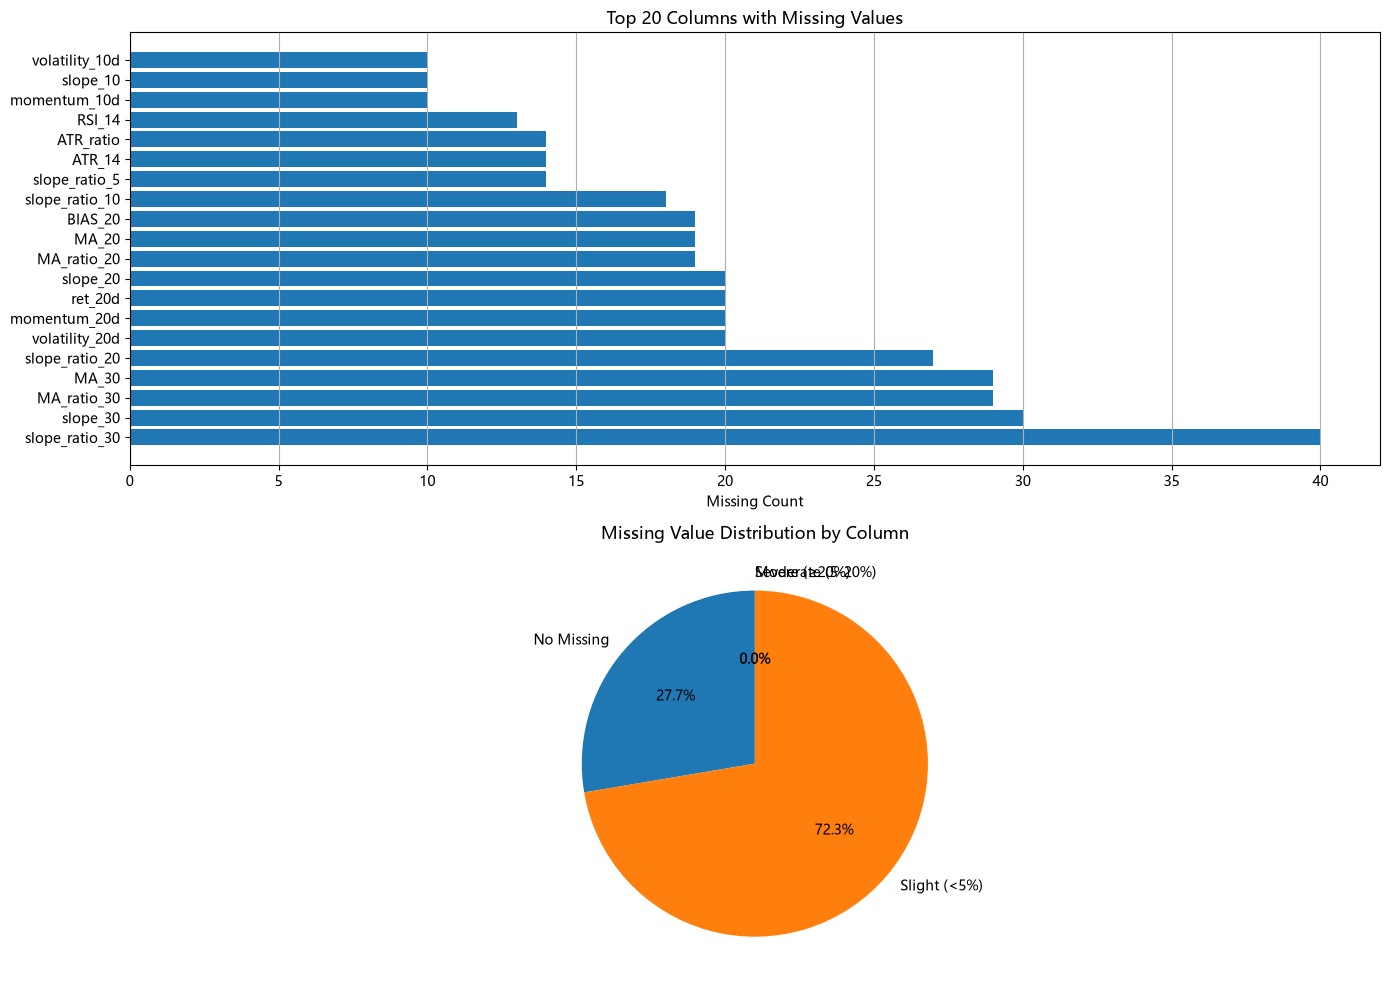


2. 删除缺失值行
删除前行数: 24678
删除后行数: 24617
删除行数: 61
删除比例: 0.25%
删除后剩余缺失值: 0

3. 因子数据探索性分析
数值因子数量: 36

因子统计描述:
           ret_1d      ret_5d     ret_10d     ret_20d        MA_5  MA_ratio_5  \
count  24617.0000  24617.0000  24617.0000  24617.0000  24617.0000  24617.0000   
mean       1.2793      1.2657      1.2721      1.2597     18.5930      0.0004   
std        5.2554      4.6084      4.7744      4.8672     10.3859      0.7539   
min       -0.9936     -0.9938     -0.9954     -0.9944      3.5060     -0.9825   
25%       -0.5764     -0.5722     -0.5710     -0.5718     12.0300     -0.5614   
50%        0.0022      0.0031     -0.0030     -0.0020     16.1900     -0.2037   
75%        1.3505      1.3173      1.3340      1.3235     21.7680      0.3713   
max      236.8202    168.3600    153.3856    177.1849     85.4880      3.6583   

            MA_10  MA_ratio_10       MA_20  MA_ratio_20       MA_30  \
count  24617.0000   24617.0000  24617.0000   24617.0000  24617.0000   
mean      18.5934      -

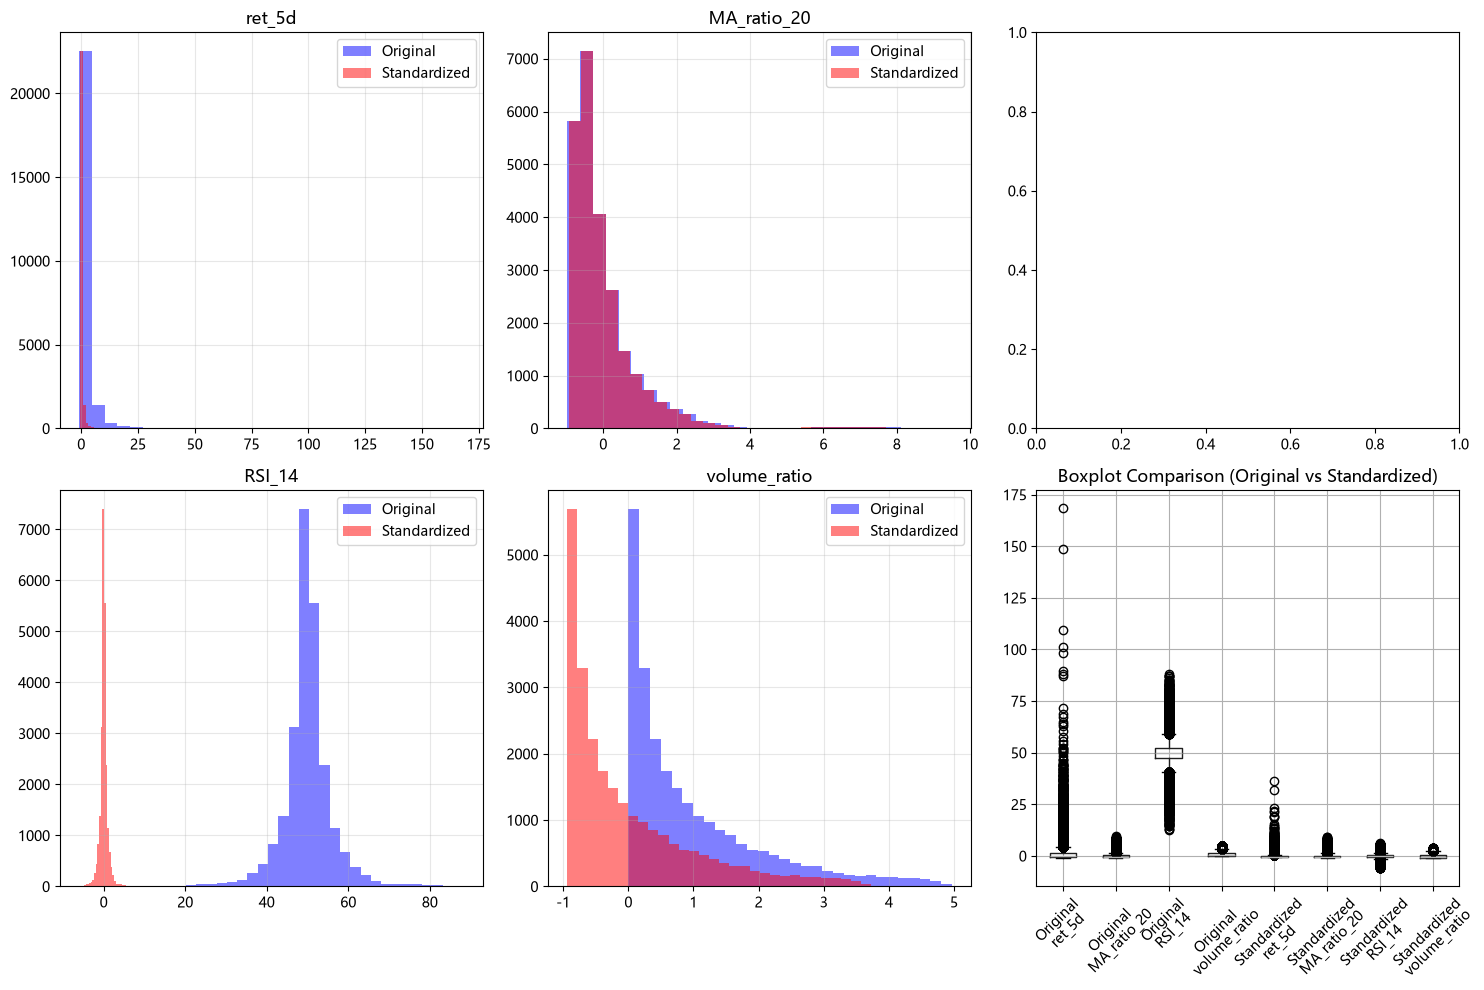


6. 因子相关性分析
高相关性因子对 (|r| > 0.8): 24对

Top 10高相关性因子对:
    Factor1      Factor2  Correlation
    ret_10d momentum_10d     1.000000
    ret_20d momentum_20d     1.000000
MA_ratio_20      BIAS_20     1.000000
MA_ratio_10      BIAS_10     1.000000
 MA_ratio_5       BIAS_5     1.000000
MA_ratio_20  MA_ratio_30     0.983654
MA_ratio_30      BIAS_20     0.983654
MA_ratio_10  MA_ratio_20     0.949351
    BIAS_10      BIAS_20     0.949351
MA_ratio_20      BIAS_10     0.949351


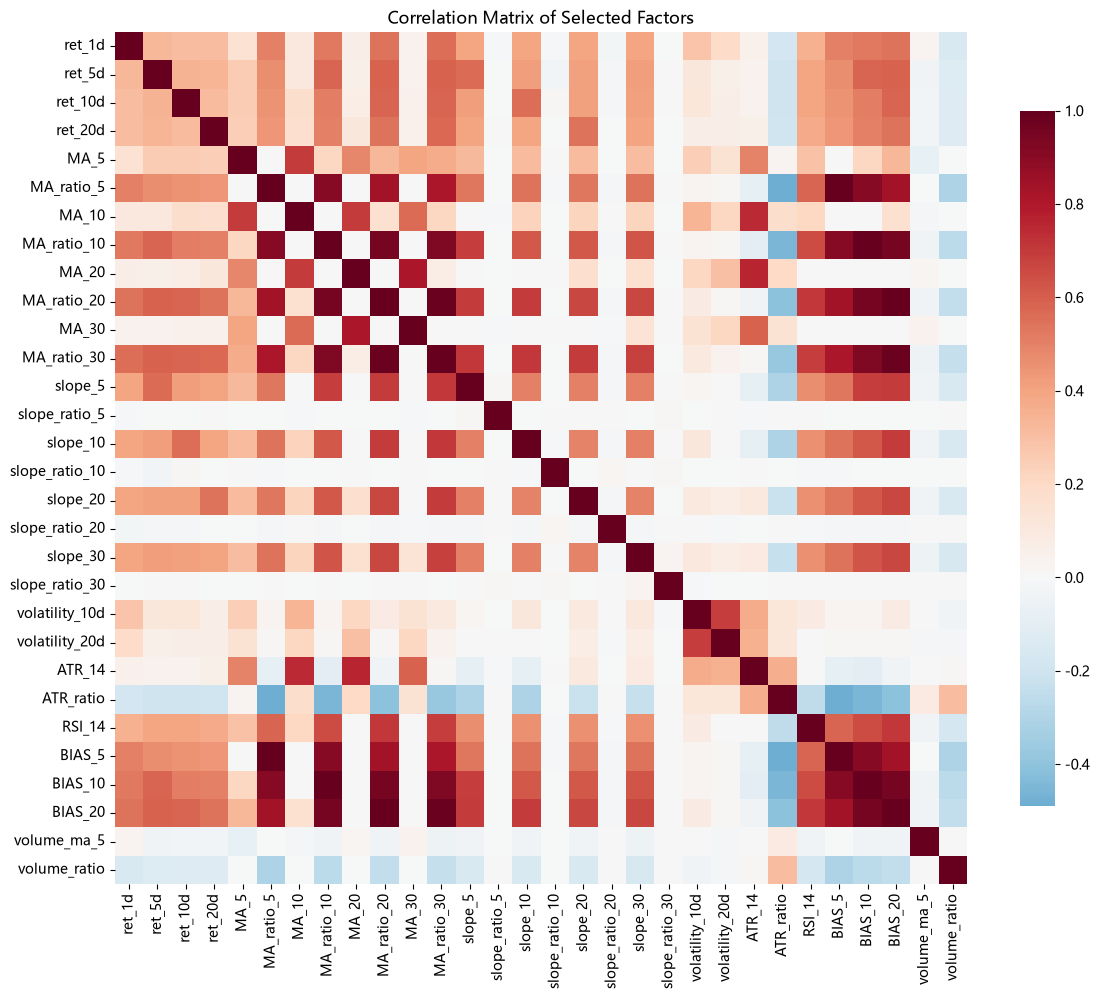


7. 数据保存
最终数据形状: (24617, 47)

8. 数据处理总结报告
            项目                      结果
         原始样本数                   24678
     删除缺失值后样本数                   24617
          删除行数                      61
          删除比例                   0.25%
          因子总数                      36
         标准化方法 Z-Score Standardization
高相关性因子对 (>0.8)                      24

✅ 数据预处理完成！


In [5]:
# ==================== 1.5 缺失值处理与数据标准化 ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 承接前面的因子计算
# df_factor = calculate_technical_factors(df)  # 假设已执行

print("="*70)
print("缺失值处理与数据标准化报告")
print("="*70)

# 1. 缺失值统计
print("\n" + "="*70)
print("1. 缺失值统计分析")
print("="*70)

# 计算每列的缺失值数量
missing_count = df_factor.isnull().sum()
missing_ratio = (df_factor.isnull().sum() / len(df_factor)) * 100

# 创建缺失值统计DataFrame
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Ratio(%)': missing_ratio.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"总样本数: {len(df_factor)}")
print(f"总因子数: {len(df_factor.columns)}")
print(f"\n存在缺失值的列数: {len(missing_df)}")

if len(missing_df) > 0:
    print("\n缺失值详情 (Top 20):")
    print(missing_df.head(20).to_string(index=False))
    
    # 可视化缺失值分布
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 缺失值数量条形图
    ax1 = axes[0]
    top_missing = missing_df.head(20)
    ax1.barh(top_missing['Column'], top_missing['Missing_Count'])
    ax1.set_xlabel('Missing Count')
    ax1.set_title('Top 20 Columns with Missing Values')
    ax1.grid(True, axis='x')
    
    # 缺失值比例饼图
    ax2 = axes[1]
    # 分类：无缺失、轻微缺失(<5%)、中等缺失(5-20%)、严重缺失(>20%)
    missing_categories = {
        'No Missing': len([x for x in missing_ratio if x == 0]),
        'Slight (<5%)': len([x for x in missing_ratio if 0 < x < 5]),
        'Moderate (5-20%)': len([x for x in missing_ratio if 5 <= x < 20]),
        'Severe (≥20%)': len([x for x in missing_ratio if x >= 20])
    }
    ax2.pie(missing_categories.values(), labels=missing_categories.keys(), 
            autopct='%1.1f%%', startangle=90)
    ax2.set_title('Missing Value Distribution by Column')
    
    plt.tight_layout()
    
    plt.show()

# 2. 删除缺失值行
print("\n" + "="*70)
print("2. 删除缺失值行")
print("="*70)

# 记录删除前的数据量
original_len = len(df_factor)

# 删除所有含有缺失值的行
df_factor_clean = df_factor.dropna()

# 删除后的数据量
cleaned_len = len(df_factor_clean)
deleted_rows = original_len - cleaned_len

print(f"删除前行数: {original_len}")
print(f"删除后行数: {cleaned_len}")
print(f"删除行数: {deleted_rows}")
print(f"删除比例: {(deleted_rows/original_len)*100:.2f}%")

# 检查是否还有缺失值
remaining_missing = df_factor_clean.isnull().sum().sum()
print(f"删除后剩余缺失值: {remaining_missing}")

# 3. 因子数据探索性分析
print("\n" + "="*70)
print("3. 因子数据探索性分析")
print("="*70)

# 选择数值型因子列（排除标识列）
factor_cols = [col for col in df_factor_clean.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']]
factor_data = df_factor_clean[factor_cols]

print(f"数值因子数量: {len(factor_cols)}")
print("\n因子统计描述:")
print(factor_data.describe().round(4))

# 检测异常值（使用IQR方法）
print("\n" + "="*70)
print("4. 异常值检测")
print("="*70)

def detect_outliers_iqr(data, column):
    """使用IQR方法检测异常值"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_summary = []
for col in factor_cols[:20]:  # 检查前20个因子
    n_outliers, lb, ub = detect_outliers_iqr(factor_data, col)
    outlier_ratio = n_outliers / len(factor_data) * 100
    outlier_summary.append({
        'Factor': col,
        'Outliers': n_outliers,
        'Ratio(%)': outlier_ratio,
        'Lower_Bound': lb,
        'Upper_Bound': ub
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values('Ratio(%)', ascending=False)
print("异常值检测结果 (Top 10):")
print(outlier_df.head(10).to_string(index=False))

# 4. 数据标准化
print("\n" + "="*70)
print("5. 数据标准化/归一化")
print("="*70)

# 4.1 Z-Score标准化
print("\n5.1 Z-Score标准化 (StandardScaler)")
print("-" * 50)
scaler_standard = StandardScaler()
factor_data_standard = scaler_standard.fit_transform(factor_data)
factor_data_standard_df = pd.DataFrame(factor_data_standard, columns=factor_cols, index=factor_data.index)

print(f"标准化后数据形状: {factor_data_standard_df.shape}")
print("标准化后统计特征:")
print(pd.DataFrame({
    'Mean': factor_data_standard_df.mean(),
    'Std': factor_data_standard_df.std()
}).head(10).round(4))

# 4.2 Min-Max归一化
print("\n5.2 Min-Max归一化 (MinMaxScaler)")
print("-" * 50)
scaler_minmax = MinMaxScaler()
factor_data_minmax = scaler_minmax.fit_transform(factor_data)
factor_data_minmax_df = pd.DataFrame(factor_data_minmax, columns=factor_cols, index=factor_data.index)

print(f"归一化后数据形状: {factor_data_minmax_df.shape}")
print("归一化后统计特征 (应全部在0-1之间):")
print(pd.DataFrame({
    'Min': factor_data_minmax_df.min(),
    'Max': factor_data_minmax_df.max(),
    'Mean': factor_data_minmax_df.mean()
}).head(10).round(4))

# 4.3 可视化标准化前后对比
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 选择4个代表性因子
sample_factors = ['ret_5d', 'MA_ratio_20', 'RSI_14', 'volume_ratio']
sample_cols = sample_factors + ['volatility_20d']

for idx, col in enumerate(sample_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    
    # 原始数据
    ax.hist(factor_data[col].dropna(), bins=30, alpha=0.5, label='Original', color='blue')
    # 标准化后数据
    ax.hist(factor_data_standard_df[col].dropna(), bins=30, alpha=0.5, label='Standardized', color='red')
    ax.set_title(f'{col}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# 箱线图对比
ax5 = axes[1, 2]
# 选择几个因子绘制箱线图
box_data = factor_data[sample_cols[:4]]
box_data.columns = [f'Original\n{c}' for c in box_data.columns]
box_std_data = factor_data_standard_df[sample_cols[:4]]
box_std_data.columns = [f'Standardized\n{c}' for c in box_std_data.columns]
combined_data = pd.concat([box_data, box_std_data], axis=1)
combined_data.boxplot(ax=ax5, rot=45)
ax5.set_title('Boxplot Comparison (Original vs Standardized)')

plt.tight_layout()
plt.show()

# 5. 相关性分析
print("\n" + "="*70)
print("6. 因子相关性分析")
print("="*70)

# 计算相关系数矩阵
corr_matrix = factor_data.corr()

# 找出高相关性的因子对
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Factor1': corr_matrix.columns[i],
                'Factor2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)

print(f"高相关性因子对 (|r| > 0.8): {len(high_corr_df)}对")
if len(high_corr_df) > 0:
    print("\nTop 10高相关性因子对:")
    print(high_corr_df.head(10).to_string(index=False))

# 可视化相关性矩阵（选择部分因子）
fig, ax = plt.subplots(figsize=(12, 10))
selected_for_corr = factor_cols[:30]  # 选择前30个因子
sns.heatmap(corr_matrix.loc[selected_for_corr, selected_for_corr], 
            annot=False, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, 
            cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix of Selected Factors')
plt.tight_layout()
plt.show()

# 6. 保存处理后的数据
print("\n" + "="*70)
print("7. 数据保存")
print("="*70)

# 合并标准化后的数据与原始数据中的标识列
df_final = df_factor_clean[['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']].copy()
df_final[factor_cols] = factor_data_standard_df


print(f"最终数据形状: {df_final.shape}")

# 7. 处理报告总结
print("\n" + "="*70)
print("8. 数据处理总结报告")
print("="*70)

summary_report = {
    '项目': [
        '原始样本数',
        '删除缺失值后样本数',
        '删除行数',
        '删除比例',
        '因子总数',
        '标准化方法',
        '高相关性因子对 (>0.8)'
    ],
    '结果': [
        original_len,
        cleaned_len,
        deleted_rows,
        f'{(deleted_rows/original_len)*100:.2f}%',
        len(factor_cols),
        'Z-Score Standardization',
        len(high_corr_df)
    ]
}

summary_df = pd.DataFrame(summary_report)
print(summary_df.to_string(index=False))

print("\n✅ 数据预处理完成！")

OLS回归假设检验报告

样本数量: 24650
特征数量: 16

2.1 OLS回归结果
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     196.8
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:00:07   Log-Likelihood:                -74557.
No. Observations:               24650   AIC:                         1.491e+05
Df Residuals:                   24635   BIC:                         1.493e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

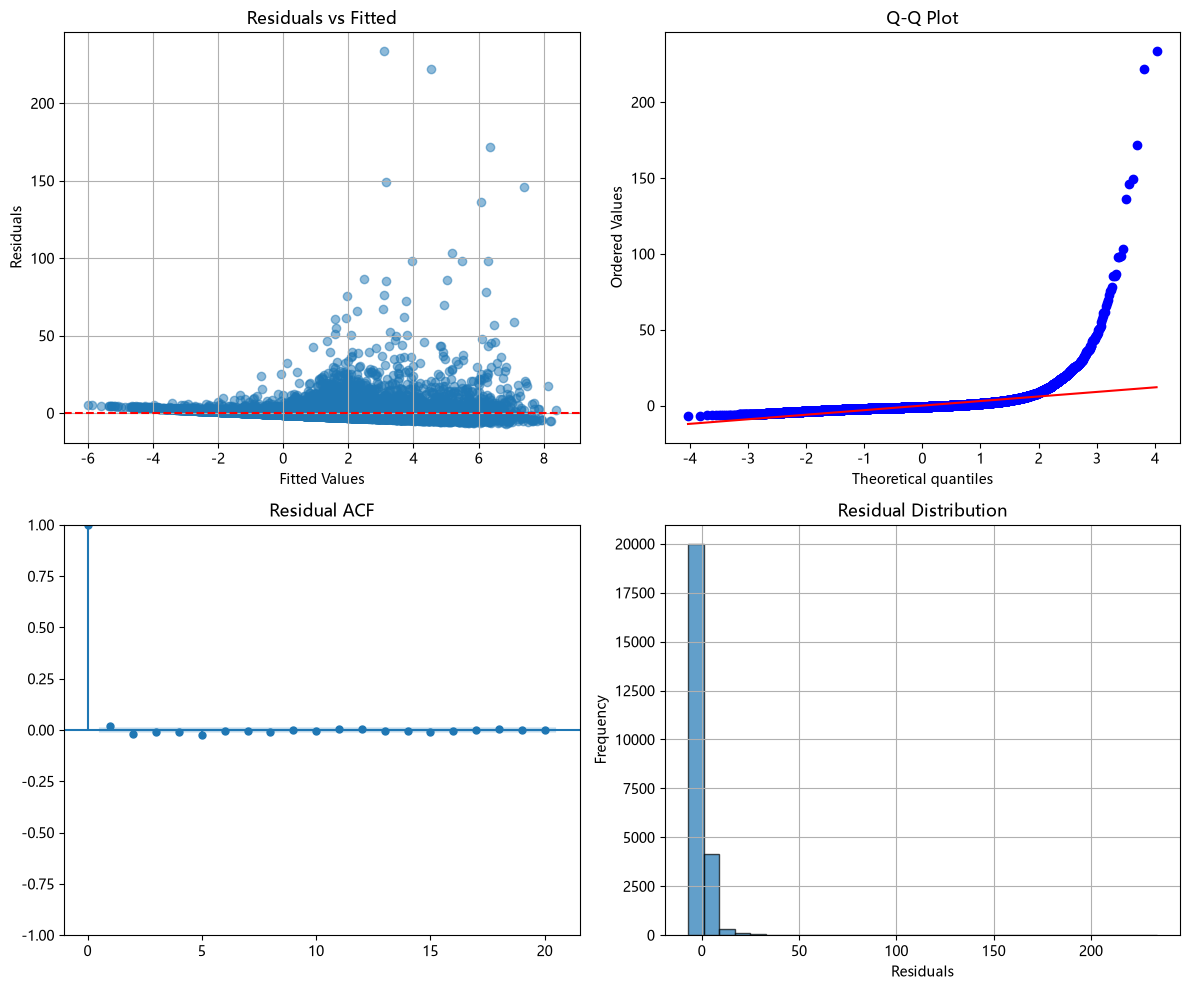

In [6]:
# ==================== 2. OLS回归假设检验 ====================

def ols_diagnostic_analysis(df_factor):
    """完整的OLS回归假设诊断"""
    
    # 准备数据：用前一天的因子预测第二天的收益率
    df_model = df_factor.copy()
    
    # 目标变量：未来1日收益率
    df_model['target'] = df_model['close'].shift(-1) / df_model['close'] - 1
    
    # 选择特征（避免过多共线性，选择代表性因子）
    feature_cols = [
        'ret_5d', 'ret_10d', 'ret_20d',
        'MA_ratio_5', 'MA_ratio_10', 'MA_ratio_20',
        'slope_20', 'slope_ratio_20',
        'volatility_10d', 'volatility_20d',
        'RSI_14', 'BIAS_10',
        'volume_ratio', 'amount_ratio',
        'close_position', 'momentum_10d'
    ]
    
    # 删除缺失值
    df_model_clean = df_model[feature_cols + ['target']].dropna()
    
    X = df_model_clean[feature_cols]
    y = df_model_clean['target']
    
    print("="*70)
    print("OLS回归假设检验报告")
    print("="*70)
    print(f"\n样本数量: {len(X)}")
    print(f"特征数量: {len(feature_cols)}")
    
    # 2.1 拟合OLS模型
    X_with_const = sm.add_constant(X)
    model_ols = sm.OLS(y, X_with_const).fit()
    
    print("\n" + "="*70)
    print("2.1 OLS回归结果")
    print("="*70)
    print(model_ols.summary())
    
    # 2.2 多重共线性诊断 - VIF
    print("\n" + "="*70)
    print("2.2 多重共线性诊断 (VIF)")
    print("="*70)
    
    vif_data = pd.DataFrame()
    vif_data['Variable'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_data = vif_data.sort_values('VIF', ascending=False)
    print(vif_data.to_string(index=False))
    
    # VIF警告
    high_vif = vif_data[vif_data['VIF'] > 10]
    if len(high_vif) > 0:
        print(f"\n⚠️ 警告: 以下因子存在严重多重共线性 (VIF > 10):")
        print(high_vif.to_string(index=False))
    else:
        print("\n✅ VIF检验通过: 所有因子VIF < 10，无明显多重共线性")
    
    # 2.3 异方差诊断 - Breusch-Pagan检验
    print("\n" + "="*70)
    print("2.3 异方差诊断 (Breusch-Pagan检验)")
    print("="*70)
    
    bp_test = het_breuschpagan(model_ols.resid, X_with_const)
    bp_labels = ['LM统计量', 'LM p值', 'F统计量', 'F p值']
    bp_results = dict(zip(bp_labels, bp_test))
    
    print(f"LM统计量: {bp_results['LM统计量']:.4f}")
    print(f"LM p值: {bp_results['LM p值']:.4f}")
    print(f"F统计量: {bp_results['F统计量']:.4f}")
    print(f"F p值: {bp_results['F p值']:.4f}")
    
    if bp_results['LM p值'] < 0.05:
        print("\n⚠️ 拒绝原假设: 存在异方差性")
        print("建议: 使用HC3稳健标准误")
    else:
        print("\n✅ 无法拒绝原假设: 同方差性")
    
    # 2.4 自相关诊断 - Durbin-Watson和Breusch-Godfrey
    print("\n" + "="*70)
    print("2.4 自相关诊断")
    print("="*70)
    
    # Durbin-Watson检验
    dw_stat = durbin_watson(model_ols.resid)
    print(f"Durbin-Watson统计量: {dw_stat:.4f}")
    if dw_stat < 1.5:
        print("⚠️ 存在正自相关")
    elif dw_stat > 2.5:
        print("⚠️ 存在负自相关")
    else:
        print("✅ 无明显自相关")
    
    # Breusch-Godfrey检验 - 使用修正后的函数名
    try:
        from statsmodels.stats.diagnostic import acorr_breusch_godfrey
        bg_test = acorr_breusch_godfrey(model_ols, nlags=5)
        print(f"\nBreusch-Godfrey检验 (滞后5阶):")
        print(f"LM统计量: {bg_test[0]:.4f}")
        print(f"LM p值: {bg_test[1]:.4f}")
        
        if bg_test[1] < 0.05:
            print("⚠️ 拒绝原假设: 存在自相关")
            print("建议: 使用HAC稳健标准误")
        else:
            print("✅ 无法拒绝原假设: 无自相关")
    except Exception as e:
        print(f"\nBG检验跳过: {e}")
    
    # 2.5 使用稳健标准误修正
    print("\n" + "="*70)
    print("2.5 使用HAC稳健标准误修正 (Newey-West)")
    print("="*70)
    
    try:
        model_hac = model_ols.get_robustcov_results(cov_type='HAC', maxlags=5)
        print("\n修正后的回归结果:")
        print(model_hac.summary())
    except Exception as e:
        print(f"HAC修正失败: {e}")
        model_hac = model_ols
    
    # 2.6 残差诊断图
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 残差vs拟合值
    axes[0, 0].scatter(model_ols.fittedvalues, model_ols.resid, alpha=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='--')
    axes[0, 0].set_xlabel('Fitted Values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].grid(True)
    
    # Q-Q图
    from scipy import stats
    stats.probplot(model_ols.resid, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot')
    
    # 残差自相关
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(model_ols.resid, ax=axes[1, 0], lags=20)
    axes[1, 0].set_title('Residual ACF')
    
    # 残差直方图
    axes[1, 1].hist(model_ols.resid, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Residuals')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Residual Distribution')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    
    plt.show()
    
    return model_ols, model_hac, vif_data

model_ols, model_hac, vif_data = ols_diagnostic_analysis(df_factor)

In [7]:
# ==================== 3. CAPM模型与局限性分析 ====================

def capm_analysis(df_factor):
    """CAPM模型分析"""
    
    print("\n" + "="*70)
    print("3. CAPM模型分析")
    print("="*70)
    
    df_capm = df_factor.copy()
    
    # 计算无风险利率 (假设为2.5%年化)
    rf_annual = 0.025
    rf_daily = rf_annual / 252
    
    # 计算超额收益
    df_capm['ret_daily'] = df_capm['close'].pct_change()
    df_capm['ret_excess'] = df_capm['ret_daily'] - rf_daily
    
    # 市场收益率 (使用20日均线收益率作为基准)
    df_capm['market_ret'] = df_capm['close'].pct_change(20)
    df_capm['market_excess'] = df_capm['market_ret'] - rf_daily
    
    # CAPM回归
    capm_data = df_capm[['ret_excess', 'market_excess']].dropna()
    
    X_capm = sm.add_constant(capm_data['market_excess'])
    y_capm = capm_data['ret_excess']
    
    capm_model = sm.OLS(y_capm, X_capm).fit()
    
    print("\nCAPM回归结果:")
    print(capm_model.summary())
    
    beta = capm_model.params['market_excess']
    alpha = capm_model.params['const']
    
    print("\n" + "="*70)
    print("CAPM模型参数估计:")
    print("="*70)
    print(f"Alpha (α): {alpha:.6f} ({(alpha*252*100):.2f}% 年化)")
    print(f"Beta (β): {beta:.4f}")
    print(f"R²: {capm_model.rsquared:.4f}")
    
    # 3.1 CAPM的局限性
    print("\n" + "="*70)
    print("3.1 CAPM模型的局限性分析")
    print("="*70)
    
    limitations = {
        "1. 单一因子": "CAPM仅考虑市场风险，忽略了规模、价值、动量等其他风险因子",
        "2. 市场组合不可观测": "理论上应包含所有资产，实践中使用指数代理存在误差",
        "3. 假设条件过于理想": "如无交易成本、投资者同质预期、无税收等在实际中不成立",
        "4. 实证表现不佳": "大量实证研究表明，低Beta股票反而可能获得更高收益",
        "5. 时变性Beta": "Beta并非恒定不变，会随市场环境变化而变化",
        "6. 非正态分布": "收益率往往具有尖峰厚尾特征，不符合CAPM的正态假设"
    }
    
    for key, value in limitations.items():
        print(f"\n{key}: {value}")
    
    return capm_model, beta, alpha

capm_model, beta, alpha = capm_analysis(df_factor)


3. CAPM模型分析

CAPM回归结果:
                            OLS Regression Results                            
Dep. Variable:             ret_excess   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     2512.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        09:51:33   Log-Likelihood:                -74689.
No. Observations:               24658   AIC:                         1.494e+05
Df Residuals:                   24656   BIC:                         1.494e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.86

In [8]:
# ==================== 4. Fama-French三因子模型 ====================

def fama_french_3factor(df_factor, capm_model):
    """Fama-French三因子模型实现"""
    
    print("\n" + "="*70)
    print("4. Fama-French三因子模型")
    print("="*70)
    
    df_ff = df_factor.copy()
    
    # 4.1 市场因子 (MKT-RF)
    rf_annual = 0.025
    rf_daily = rf_annual / 252
    
    df_ff['ret_daily'] = df_ff['close'].pct_change()
    df_ff['ret_excess'] = df_ff['ret_daily'] - rf_daily
    
    # 使用20日均线收益率作为市场组合的代理
    df_ff['market_ret'] = df_ff['close'].pct_change(20)
    df_ff['mkt_excess'] = df_ff['market_ret'] - rf_daily
    
    # 4.2 规模因子 (SMB) - 简化版本
    df_ff['market_cap'] = df_ff['vol'] * df_ff['close'] / 1000000
    
    # 使用滚动分位数
    df_ff['size_rank'] = df_ff.groupby('trade_date')['market_cap'].rank(pct=True)
    df_ff['size_group'] = df_ff['size_rank'].apply(lambda x: 'Small' if x < 0.3 else ('Big' if x > 0.7 else 'Mid'))
    
    # 计算未来收益
    df_ff['ret_next'] = df_ff['close'].shift(-1) / df_ff['close'] - 1
    
    # 计算SMB
    size_returns = df_ff.groupby(['trade_date', 'size_group'])['ret_next'].mean().unstack()
    size_returns['SMB'] = size_returns['Small'] - size_returns['Big']
    df_ff = df_ff.merge(size_returns['SMB'], left_on='trade_date', right_index=True, how='left')
    
    # 4.3 价值因子 (HML) - 使用1/price作为BM的代理
    df_ff['book_to_market'] = 1 / (df_ff['close'] + 1e-10)
    
    df_ff['bm_rank'] = df_ff.groupby('trade_date')['book_to_market'].rank(pct=True)
    df_ff['bm_group'] = df_ff['bm_rank'].apply(lambda x: 'High' if x > 0.7 else ('Low' if x < 0.3 else 'Mid'))
    
    # 计算HML
    bm_returns = df_ff.groupby(['trade_date', 'bm_group'])['ret_next'].mean().unstack()
    bm_returns['HML'] = bm_returns['High'] - bm_returns['Low']
    df_ff = df_ff.merge(bm_returns['HML'], left_on='trade_date', right_index=True, how='left')
    
    # 4.4 Fama-French三因子回归
    ff_data = df_ff[['ret_excess', 'mkt_excess', 'SMB', 'HML']].dropna()
    
    X_ff = sm.add_constant(ff_data[['mkt_excess', 'SMB', 'HML']])
    y_ff = ff_data['ret_excess']
    
    ff_model = sm.OLS(y_ff, X_ff).fit()
    
    print("\nFama-French三因子回归结果:")
    print(ff_model.summary())
    
    print("\n" + "="*70)
    print("三因子模型参数估计:")
    print("="*70)
    print(f"Alpha (α): {ff_model.params['const']:.6f}")
    print(f"市场因子 (MKT-RF): {ff_model.params['mkt_excess']:.4f}")
    print(f"规模因子 (SMB): {ff_model.params['SMB']:.4f}")
    print(f"价值因子 (HML): {ff_model.params['HML']:.4f}")
    print(f"R²: {ff_model.rsquared:.4f}")
    
    # 与CAPM比较
    print("\n" + "="*70)
    print("CAPM vs Fama-French三因子比较:")
    print("="*70)
    print(f"CAPM R²: {capm_model.rsquared:.4f}")
    print(f"FF三因子 R²: {ff_model.rsquared:.4f}")
    print(f"R²改进: {ff_model.rsquared - capm_model.rsquared:.4f}")
    
    return ff_model, df_ff

ff_model, df_ff = fama_french_3factor(df_factor, capm_model)


4. Fama-French三因子模型

Fama-French三因子回归结果:
                            OLS Regression Results                            
Dep. Variable:             ret_excess   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     880.1
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:10:25   Log-Likelihood:                -74631.
No. Observations:               24658   AIC:                         1.493e+05
Df Residuals:                   24654   BIC:                         1.493e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     


5. Lasso回归因子筛选

正在执行Lasso交叉验证...

最优alpha: 0.010985
交叉验证R²: 0.1657

Lasso筛选结果 (非零系数因子):

筛选出的因子数量: 22/29

Top 10重要因子:
       feature  coefficient  abs_coef
     ATR_ratio     1.695818  1.695818
  volume_ratio     0.754300  0.754300
  amount_ratio    -0.634898  0.634898
   MA_ratio_30    -0.207069  0.207069
       slope_5     0.206625  0.206625
      slope_10     0.175938  0.175938
volatility_20d    -0.163895  0.163895
volatility_10d    -0.152582  0.152582
        RSI_14    -0.145132  0.145132
      slope_30    -0.102335  0.102335


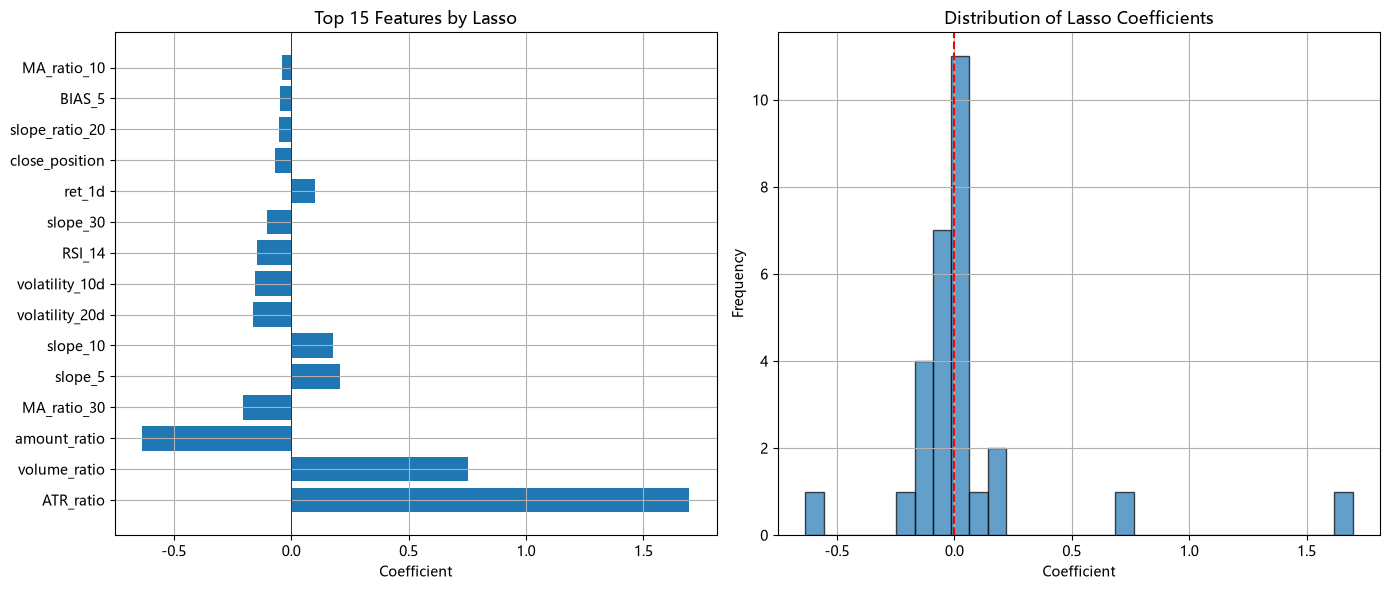

In [10]:
# ==================== 5. Lasso回归筛选因子====================

def lasso_feature_selection(df_factor):
    """使用Lasso回归进行因子筛选"""
    
    print("\n" + "="*70)
    print("5. Lasso回归因子筛选")
    print("="*70)
    
    df_lasso = df_factor.copy()
    
    # 构建特征集
    feature_cols_lasso = [
        'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d',
        'MA_ratio_5', 'MA_ratio_10', 'MA_ratio_20', 'MA_ratio_30',
        'slope_5', 'slope_10', 'slope_20', 'slope_30',
        'slope_ratio_5', 'slope_ratio_10', 'slope_ratio_20', 'slope_ratio_30',
        'volatility_10d', 'volatility_20d',
        'RSI_14',
        'BIAS_5', 'BIAS_10', 'BIAS_20',
        'volume_ratio', 'amount_ratio',
        'high_low_ratio', 'close_position',
        'momentum_10d', 'momentum_20d',
        'ATR_ratio'
    ]
    
    # 目标变量
    df_lasso['target'] = df_lasso['close'].shift(-1) / df_lasso['close'] - 1
    
    # 删除缺失值
    df_lasso_clean = df_lasso[feature_cols_lasso + ['target']].dropna()
    
    X = df_lasso_clean[feature_cols_lasso]
    y = df_lasso_clean['target']
    
    # 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 时间序列交叉验证
    tscv = TimeSeriesSplit(n_splits=5)
    
    # LassoCV选择最优alpha
    print("\n正在执行Lasso交叉验证...")
    lasso_cv = LassoCV(
        cv=tscv,
        alphas=np.logspace(-4, 0, 50),
        random_state=42,
        max_iter=10000
    )
    lasso_cv.fit(X_scaled, y)
    
    print(f"\n最优alpha: {lasso_cv.alpha_:.6f}")
    print(f"交叉验证R²: {lasso_cv.score(X_scaled, y):.4f}")
    
    # 获取系数
    coefficients = pd.DataFrame({
        'feature': feature_cols_lasso,
        'coefficient': lasso_cv.coef_
    })
    coefficients['abs_coef'] = abs(coefficients['coefficient'])
    coefficients = coefficients.sort_values('abs_coef', ascending=False)
    
    print("\n" + "="*70)
    print("Lasso筛选结果 (非零系数因子):")
    print("="*70)
    
    selected_features = coefficients[abs(coefficients['coefficient']) > 1e-6]
    print(f"\n筛选出的因子数量: {len(selected_features)}/{len(feature_cols_lasso)}")
    print("\nTop 10重要因子:")
    print(selected_features.head(10).to_string(index=False))
    
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 特征重要性
    ax1 = axes[0]
    top_features = selected_features.head(15)
    ax1.barh(top_features['feature'], top_features['coefficient'])
    ax1.set_xlabel('Coefficient')
    ax1.set_title('Top 15 Features by Lasso')
    ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax1.grid(True)
    
    # 系数分布
    ax2 = axes[1]
    ax2.hist(lasso_cv.coef_, bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--')
    ax2.set_xlabel('Coefficient')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Lasso Coefficients')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return lasso_cv, selected_features['feature'].tolist(), X_scaled, y

lasso_model, selected_features, X_scaled, y_lasso = lasso_feature_selection(df_factor)


6. 随机森林非线性因子合成
训练集大小: 19707
测试集大小: 4927

6.1 随机森林回归模型
--------------------------------------------------
训练集 MSE: 16.303835
测试集 MSE: 15.331691
训练集 R²: 0.4563
测试集 R²: 0.1500

6.2 随机森林特征重要性
--------------------------------------------------

Top 10重要特征:
       feature  importance
   MA_ratio_30    0.501065
volatility_10d    0.072997
        ret_1d    0.047301
high_low_ratio    0.041693
      slope_30    0.041223
        RSI_14    0.034876
slope_ratio_10    0.033809
slope_ratio_20    0.023748
  amount_ratio    0.023665
        BIAS_5    0.022768


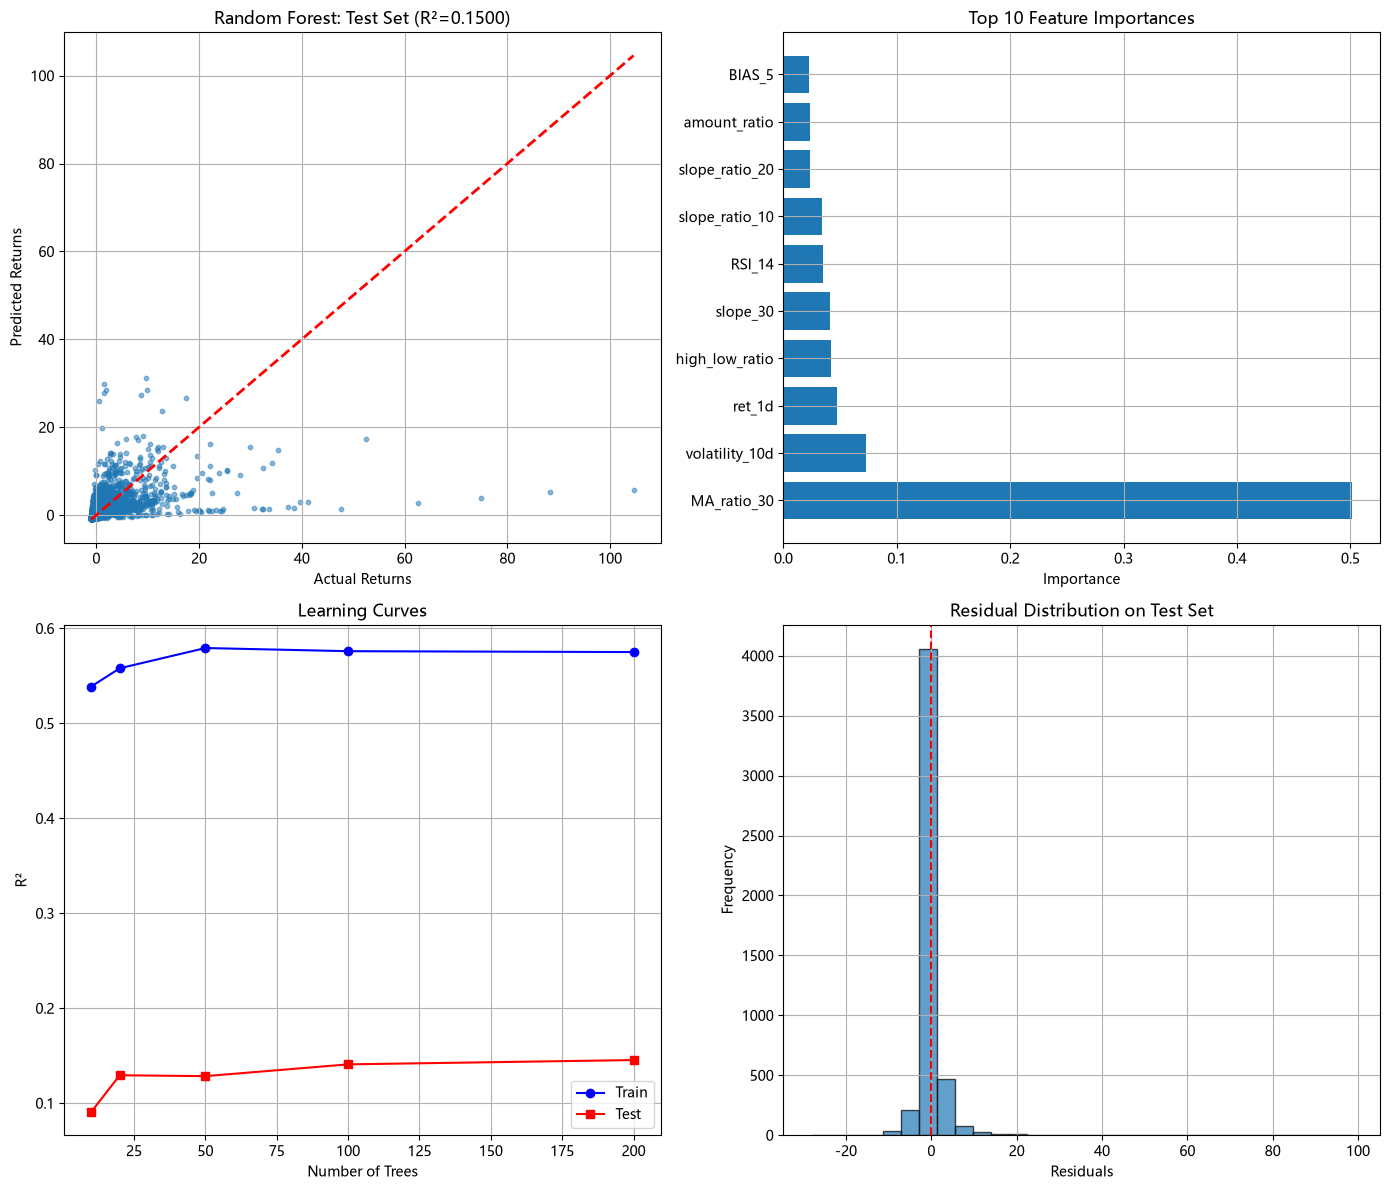

In [11]:
# ==================== 6. 随机森林非线性因子合成====================

def random_forest_factor_synthesis(df_factor, selected_features):
    """使用随机森林进行非线性因子合成"""
    
    print("\n" + "="*70)
    print("6. 随机森林非线性因子合成")
    print("="*70)
    
    df_rf = df_factor.copy()
    df_rf['target'] = df_rf['close'].shift(-1) / df_rf['close'] - 1
    
    # 准备数据
    df_rf_clean = df_rf[selected_features + ['target']].dropna()
    
    X = df_rf_clean[selected_features]
    y = df_rf_clean['target']
    
    # 时间序列划分
    split_idx = int(len(X) * 0.8)
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    
    # 标准化
    scaler_rf = StandardScaler()
    X_train_scaled = scaler_rf.fit_transform(X_train)
    X_test_scaled = scaler_rf.transform(X_test)
    
    print(f"训练集大小: {len(X_train)}")
    print(f"测试集大小: {len(X_test)}")
    
    # 6.1 随机森林模型
    print("\n6.1 随机森林回归模型")
    print("-" * 50)
    
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_scaled, y_train)
    
    # 预测
    y_pred_train = rf_model.predict(X_train_scaled)
    y_pred_test = rf_model.predict(X_test_scaled)
    
    # 评估
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"训练集 MSE: {train_mse:.6f}")
    print(f"测试集 MSE: {test_mse:.6f}")
    print(f"训练集 R²: {train_r2:.4f}")
    print(f"测试集 R²: {test_r2:.4f}")
    
    # 6.2 特征重要性
    print("\n6.2 随机森林特征重要性")
    print("-" * 50)
    
    feature_importance = pd.DataFrame({
        'feature': selected_features,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10重要特征:")
    print(feature_importance.head(10).to_string(index=False))
    
    # 6.3 可视化
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 预测vs实际
    ax1 = axes[0, 0]
    ax1.scatter(y_test, y_pred_test, alpha=0.5, s=10)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax1.set_xlabel('Actual Returns')
    ax1.set_ylabel('Predicted Returns')
    ax1.set_title(f'Random Forest: Test Set (R²={test_r2:.4f})')
    ax1.grid(True)
    
    # 特征重要性
    ax2 = axes[0, 1]
    top_imp = feature_importance.head(10)
    ax2.barh(top_imp['feature'], top_imp['importance'])
    ax2.set_xlabel('Importance')
    ax2.set_title('Top 10 Feature Importances')
    ax2.grid(True)
    
    # 学习曲线
    ax3 = axes[1, 0]
    train_scores = []
    test_scores = []
    n_estimators_range = [10, 20, 50, 100, 200]
    
    for n in n_estimators_range:
        rf_temp = RandomForestRegressor(
            n_estimators=n,
            max_depth=10,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        )
        rf_temp.fit(X_train_scaled, y_train)
        train_scores.append(rf_temp.score(X_train_scaled, y_train))
        test_scores.append(rf_temp.score(X_test_scaled, y_test))
    
    ax3.plot(n_estimators_range, train_scores, 'b-', label='Train', marker='o')
    ax3.plot(n_estimators_range, test_scores, 'r-', label='Test', marker='s')
    ax3.set_xlabel('Number of Trees')
    ax3.set_ylabel('R²')
    ax3.set_title('Learning Curves')
    ax3.legend()
    ax3.grid(True)
    
    # 残差分布
    ax4 = axes[1, 1]
    residuals = y_test - y_pred_test
    ax4.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    ax4.axvline(x=0, color='red', linestyle='--')
    ax4.set_xlabel('Residuals')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Residual Distribution on Test Set')
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return rf_model, feature_importance, df_rf

rf_model, feature_importance, df_rf_final = random_forest_factor_synthesis(df_factor, selected_features)